In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Dataset.csv')


Saving Dataset.csv to Dataset.csv


In [ ]:
#LOAD THE DATASET

In [ ]:
df.head()

,CustomerID,Name,Gender,Age,City,MonthlyIncome,SignupDate,LastPurchaseDate,ProductsPurchased,SpendingScore,PreferredChannel,CustomerSatisfaction,Churn
0,1,Patrick Sanchez,Female,25,Abuja,63112,09/02/2026,26/11/2027,8,95,Online,4.2,0
1,2,Megan Mcclain,Male,45,Abuja,66663,25/12/2023,21/08/2025,8,4,Mobile App,3.8,0
2,3,Amanda Davis,Female,59,Abuja,417696,05/10/2023,08/10/2025,15,70,Mobile App,2.8,0
3,4,Alyssa Gonzalez,Female,28,Port Harcourt,416026,18/05/2024,05/07/2026,5,55,Online,4.9,1
4,5,Jennifer Cole,Female,23,Port Harcourt,249191,25/02/2026,10/06/2026,20,13,Store,4.4,1


In [ ]:
#CHECK FOR MISSING VALUES
df.isnull().sum()

,0
CustomerID,0
Name,0
Gender,0
Age,0
City,0
MonthlyIncome,0
SignupDate,0
LastPurchaseDate,0
ProductsPurchased,0
SpendingScore,0


In [ ]:
# REMOVE DUPLICATES
df = df.drop_duplicates()
df.head()


,CustomerID,Name,Gender,Age,City,MonthlyIncome,SignupDate,LastPurchaseDate,ProductsPurchased,SpendingScore,PreferredChannel,CustomerSatisfaction,Churn
0,1,Patrick Sanchez,Female,25,Abuja,63112,09/02/2026,26/11/2027,8,95,Online,4.2,0
1,2,Megan Mcclain,Male,45,Abuja,66663,25/12/2023,21/08/2025,8,4,Mobile App,3.8,0
2,3,Amanda Davis,Female,59,Abuja,417696,05/10/2023,08/10/2025,15,70,Mobile App,2.8,0
3,4,Alyssa Gonzalez,Female,28,Port Harcourt,416026,18/05/2024,05/07/2026,5,55,Online,4.9,1
4,5,Jennifer Cole,Female,23,Port Harcourt,249191,25/02/2026,10/06/2026,20,13,Store,4.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Mrs. Taylor Smith,Male,53,Lagos,124120,05/03/2024,23/09/2025,19,16,Mobile App,3.2,0
496,497,Paul Finley,Female,31,Abuja,442322,07/01/2025,16/11/2025,14,95,Mobile App,4.6,0
497,498,Laura Green,Female,29,Abuja,165756,03/09/2024,15/02/2025,4,79,Online,4.0,0
498,499,Amy Wilson,Male,53,Port Harcourt,291835,01/12/2024,22/04/2027,22,83,Online,2.8,0


In [ ]:
#CREATING AGE GROUP  NUMPY
condition = [df['Age']<35,(df['Age'] >=35) & (df['Age'] <=45), df['Age'] >45]
labels = ['Young', 'Middle-Age', 'Old']
df['Age_Group'] = np.select( condition, labels, default='Unknown')
df.head()




,CustomerID,Name,Gender,Age,City,MonthlyIncome,SignupDate,LastPurchaseDate,ProductsPurchased,SpendingScore,PreferredChannel,CustomerSatisfaction,Churn,Age_Group
0,1,Patrick Sanchez,Female,25,Abuja,63112,09/02/2026,26/11/2027,8,95,Online,4.2,0,Young
1,2,Megan Mcclain,Male,45,Abuja,66663,25/12/2023,21/08/2025,8,4,Mobile App,3.8,0,Middle-Age
2,3,Amanda Davis,Female,59,Abuja,417696,05/10/2023,08/10/2025,15,70,Mobile App,2.8,0,Old
3,4,Alyssa Gonzalez,Female,28,Port Harcourt,416026,18/05/2024,05/07/2026,5,55,Online,4.9,1,Young
4,5,Jennifer Cole,Female,23,Port Harcourt,249191,25/02/2026,10/06/2026,20,13,Store,4.4,1,Young


In [ ]:
#CREATING AGE GROUP USING PANDAS

In [ ]:
# CREATE AGE GROUPS USING PANDAS
# This matches the NumPy definition above: Young < 35, Middle-Age 35-45, Old > 45.
bins = [0, 35, 46, float('inf')]
labels = ['Young', 'Middle-Age', 'Old']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df.head()


In [ ]:
#REODER TABLES SO AGE GROUP IS AFTER AGE

In [ ]:
cols = df.columns.tolist()
Age_index = cols.index('Age')
cols.remove('Age_Group')
cols.insert(Age_index+1, 'Age_Group')
df= df[cols]
df.head()

,CustomerID,Name,Gender,Age,Age_Group,City,MonthlyIncome,SignupDate,LastPurchaseDate,ProductsPurchased,SpendingScore,PreferredChannel,CustomerSatisfaction,Churn
0,1,Patrick Sanchez,Female,25,Young,Abuja,63112,09/02/2026,26/11/2027,8,95,Online,4.2,0
1,2,Megan Mcclain,Male,45,Middle-Age,Abuja,66663,25/12/2023,21/08/2025,8,4,Mobile App,3.8,0
2,3,Amanda Davis,Female,59,Old,Abuja,417696,05/10/2023,08/10/2025,15,70,Mobile App,2.8,0
3,4,Alyssa Gonzalez,Female,28,Young,Port Harcourt,416026,18/05/2024,05/07/2026,5,55,Online,4.9,1
4,5,Jennifer Cole,Female,23,Young,Port Harcourt,249191,25/02/2026,10/06/2026,20,13,Store,4.4,1


In [ ]:
#RATE OF CHURN

churn_rate = df['Churn'].mean() *100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 51.20%


In [ ]:
#AVERAGE INCOME BY GENDER

average_income_by_gender = df.groupby('Gender')['MonthlyIncome'].mean().round(2).sort_values(ascending=False)
average_income_by_gender


,MonthlyIncome
Gender,
Male,300958.84
Female,273988.44


In [ ]:
#MONTHLY INCOME BY AGE_GROUP
AGE_GROUP = (
    df.groupby('Age_Group')['MonthlyIncome']
    .mean()
    .round(1)
    .sort_values(ascending=False))


/tmp/ipykernel_527/2578088786.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['MonthlyIncome']


In [ ]:
AGE_GROUP

,MonthlyIncome
Age_Group,
Middle-Age,300821.8
Young,291990.6
Old,274707.2


In [ ]:

df.head()

,CustomerID,Name,Gender,Age,Age_Group,City,MonthlyIncome,SignupDate,LastPurchaseDate,ProductsPurchased,SpendingScore,PreferredChannel,CustomerSatisfaction,Churn
0,1,Patrick Sanchez,Female,25,Young,Abuja,63112,09/02/2026,26/11/2027,8,95,Online,4.2,0
1,2,Megan Mcclain,Male,45,Middle-Age,Abuja,66663,25/12/2023,21/08/2025,8,4,Mobile App,3.8,0
2,3,Amanda Davis,Female,59,Old,Abuja,417696,05/10/2023,08/10/2025,15,70,Mobile App,2.8,0
3,4,Alyssa Gonzalez,Female,28,Young,Port Harcourt,416026,18/05/2024,05/07/2026,5,55,Online,4.9,1
4,5,Jennifer Cole,Female,23,Young,Port Harcourt,249191,25/02/2026,10/06/2026,20,13,Store,4.4,1


In [ ]:
#CHARTS

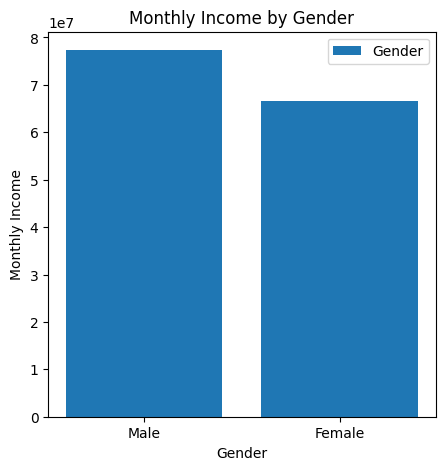

In [ ]:
# GENDER BY MONTHLY INCOME
# Use mean income so the chart agrees with the average-income analysis above.
income_data = (
    df.groupby('Gender')['MonthlyIncome']
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

plt.figure(figsize=(5,5))
plt.bar(income_data.index, income_data.values)
plt.title('Average Monthly Income by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Monthly Income')
plt.show()


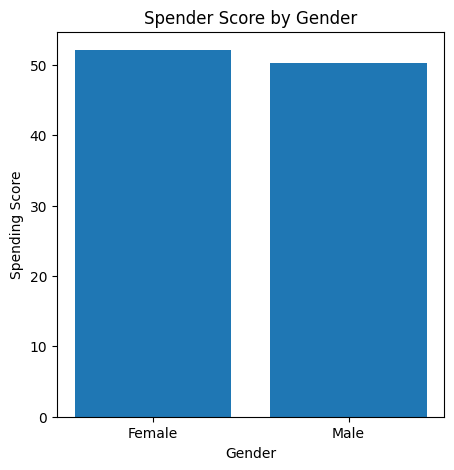

In [ ]:
# SPENDING SCORE BY GENDER
gender_data = df.groupby('Gender')['SpendingScore'].mean().sort_values(ascending=False)

plt.figure(figsize=(5,5))
plt.bar(gender_data.index, gender_data.values)
plt.title('Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score')
plt.show()


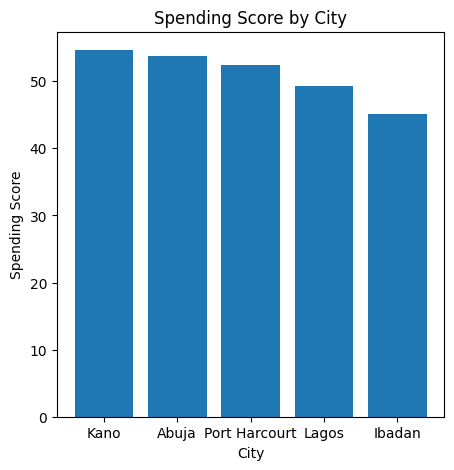

In [ ]:
# SpendingScore by City


city_data = df.groupby('City')['SpendingScore'].mean().sort_values(ascending=False)

plt.figure(figsize=(5,5))
plt.bar(city_data.index, city_data.values)

plt.title('Spending Score by City')
plt.xlabel('City')
plt.ylabel('Spending Score')

plt.show()

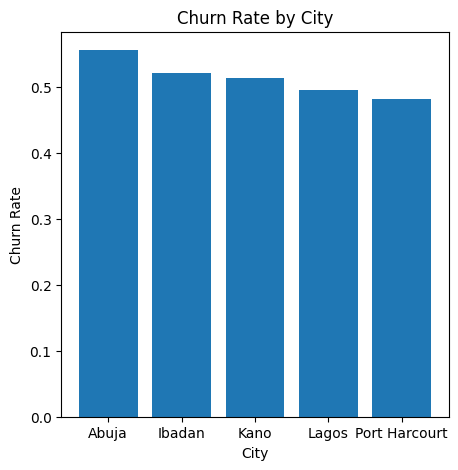

In [ ]:
# CHURN BY CITY
# Convert the mean of a 0/1 Churn variable to percentage.
churn_data = (
    df.groupby('City')['Churn']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(5,5))
plt.bar(churn_data.index, churn_data.values)
plt.title('Churn Rate by City')
plt.xlabel('City')
plt.ylabel('Churn Rate (%)')
plt.show()


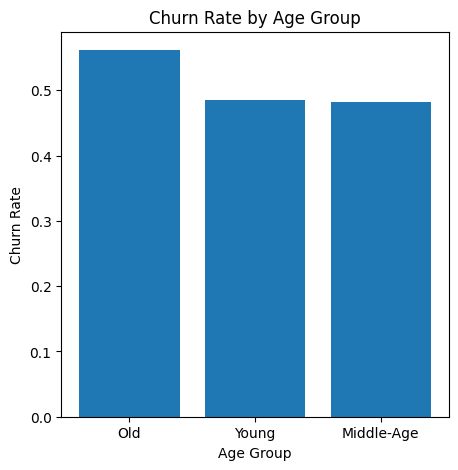

In [ ]:
# CHURN BY AGE GROUP
# Convert the mean of a 0/1 Churn variable to percentage.
churn_data = (
    df.groupby('Age_Group', observed=False)['Churn']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(5,5))
plt.bar(churn_data.index.astype(str), churn_data.values)
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.show()
